In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

pkw = "/playground-series-s6e4/working"
pps  = 'playground-series-s6e4/'
pds  = 'PS-s6e4-20/'

sub  = pd.read_csv(pps+'sample_submission.csv')


def merge(list_df):
    dfs = pd.merge(list_df[0],list_df[1], on='id')
    for i in range(2,len(list_df)): 
        dfs = pd.merge(dfs,list_df[i], on='id')
    return dfs


def microEDA(x, list_names_df): 
    lwh = []
    for _p in list_names_df:
        wh = x[_p][0:1]
        if wh=='M': wh = '_'
        lwh.append(f'{wh} ')
    return ''.join(lwh) 


def vote(lns, f_vote_schema, dfs, details=True):
    dfs['wh'] = dfs.apply(lambda x: microEDA(x,lns), axis=1)
    if details:
        display(dfs.tail(2))
        print("'L' - Low,  '_' - Medium,  'H' - High")
        print('\n', dfs['wh'].value_counts())
    df = pd.read_csv(pps+'sample_submission.csv')
    df['Irrigation_Need'] = dfs.apply(lambda x: f_vote_schema(x,lns), axis=1)
    return df


def comparison(lns,dfs, value_target):
    dfc = dfs.drop(['id','wh'],axis=1)
    def comp(x, value_target, lns):
        return [value_target if x[ln] != value_target else None for ln in lns] 
    dfc[lns] = dfc.apply(lambda x: comp(x,value_target,lns), axis=1, result_type='expand')
    return dfc


def heatmap_show(value_target, cell_axes, color_map, dfs):
    ax = cell_axes
    ax.set_title(value_target, fontsize=10)
    sns.heatmap(dfs.isnull(), cbar=False, cmap=color_map, ax=ax)


def display_heatmaps(lns,dfs,qp=5): # qp - q_uantity p_articipants
    if qp==4:
        equs = ['L L L L ','_ _ _ _ ','H H H H ']
    if qp==5:
        equs = ['L L L L L ','_ _ _ _ _ ','H H H H H ']
    if qp==6:
        equs = ['L L L L L L ','_ _ _ _ _ _ ','H H H H H H ']
    if qp==7:
        equs = ['L L L L L L L ','_ _ _ _ _ _ _ ','H H H H H H H ']
        
    dfs_loc = dfs.loc[~dfs['wh'].isin(equs)]
        
    dfs_low    = comparison(lns, dfs_loc, 'Low') 
    dfs_medium = comparison(lns, dfs_loc, 'Medium')
    dfs_high   = comparison(lns, dfs_loc, 'High')
    fig, axes = plt.subplots(2, 3, figsize=(11,4))
    heatmap_show('Low',    axes[1,0], "Blues",   dfs_low)
    heatmap_show('Medium', axes[1,1], "Blues",   dfs_medium)
    heatmap_show('High',   axes[1,2], "Blues",   dfs_high)
    heatmap_show('Low',    axes[0,0], "viridis", dfs_low)
    heatmap_show('Medium', axes[0,1], "viridis", dfs_medium)
    heatmap_show('High',   axes[0,2], "viridis", dfs_high)
    plt.show()


def f_vote_schema1(x, lns):       # without the last element, and the last one itself
    _lns,_1vs = lns[:-1],lns[-1] 
    if x[_lns[0]] == x[_lns[1]] == x[_lns[2]] == x[_lns[3]]: 
        return x[_lns[0]]         # if the first four are equal, then we return them, 
    else:
        return x[_1vs]            # otherwise the last element   


def f_vote_schema2(x, lns):
    _lns,_1vs = lns[:-1],lns[-1] 
    if x[_lns[0]]==x[_lns[1]]==x[_lns[2]]==x[_lns[3]]==x[_lns[4]]==x[_lns[5]]: 
        return x[_lns[0]]
    else:
        return x[_1vs]


def f_vote_schema3(x, lns):
    _lns,_1vs = lns[:-1],lns[-1] 
    if x[_lns[0]]==x[_lns[1]]==x[_lns[2]]==x[_lns[3]]==x[_lns[4]]: 
        return x[_lns[0]]
    else:
        return x[_1vs]


 v.1  ->  LB=0.98118 



,id,df5,df1,df2,df3,df4,df_,wh
269998,899998,Low,Low,Low,Low,Low,Low,L L L L L L
269999,899999,Medium,Medium,Medium,Medium,Medium,Medium,_ _ _ _ _ _


'L' - Low,  '_' - Medium,  'H' - High

 wh
L L L L L L     159213
_ _ _ _ _ _      99474
H H H H H H       9821
_ _ H H _ _        187
_ _ H _ _ _        160
H H _ _ H H        155
L L L _ L L        124
_ _ _ H _ _        117
_ _ L _ _ _        108
_ _ L L _ _         84
_ H _ _ _ _         80
H H _ H H H         73
H H H _ H H         57
_ H H H _ _         39
L L _ _ L L         38
L _ L L L L         33
_ H H _ _ _         22
H _ H H H H         21
_ _ _ L _ _         19
L L _ L L L         18
_ H _ H _ _         15
L _ L _ L L         13
_ L L _ _ _         11
L _ _ _ _ _         11
H _ _ _ H H         11
H _ _ H H H          8
_ _ L L L L          7
L _ _ _ L L          7
_ L _ _ _ _          6
_ _ L L L _          6
L _ L L L _          6
_ L L L _ _          6
H _ H _ H H          5
_ _ _ _ L L          5
_ _ _ _ L _          4
_ L L L L L          4
L L L L _ _          3
L _ L _ _ _          3
_ L L L _ L          3
L _ L _ L _          3
L _ L L _ L          2
_ _ _ _ _ L   

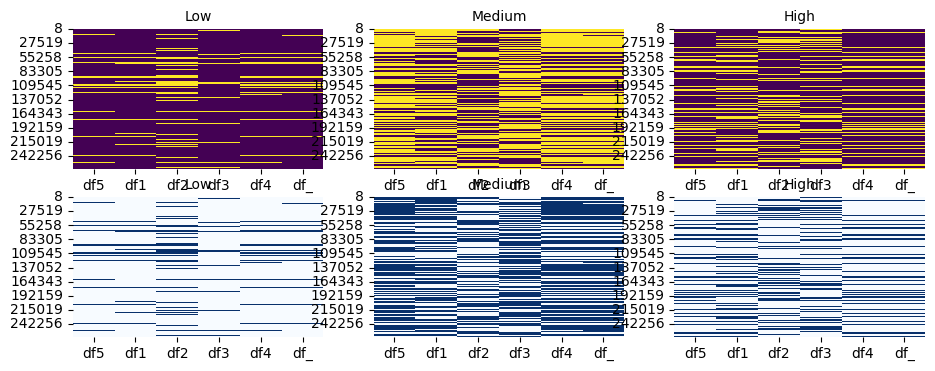


 v.2  ->  LB=0.98118 



,id,df1,df2,df3,df4,df_,wh
269998,899998,Low,Low,Low,Low,Low,L L L L L
269999,899999,Medium,Medium,Medium,Medium,Medium,_ _ _ _ _


'L' - Low,  '_' - Medium,  'H' - High

 wh
L L L L L     159217
_ _ _ _ _      99485
H H H H H       9822
_ H H _ _        187
_ H _ _ _        160
H _ _ H H        155
L L _ L L        124
_ _ H _ _        117
_ L _ _ _        111
_ L L _ _         86
H _ _ _ _         80
H _ H H H         73
H H _ H H         57
_ L L L L         40
H H H _ _         39
L _ _ L L         38
H H _ _ _         22
_ H H H H         21
_ _ L _ _         19
L _ L L L         18
H _ H _ _         15
_ L _ L L         14
L L _ _ _         13
_ _ _ L L         12
_ L L L _         12
_ _ _ H H         11
L L L _ _          9
_ _ H H H          8
L _ _ _ _          6
_ H _ H H          5
_ L _ L _          4
_ _ _ _ L          4
L L L _ L          4
_ _ _ L _          4
_ L L _ L          2
L L _ _ L          2
_ L _ _ L          2
_ _ L L L          1
L L _ L _          1
Name: count, dtype: int64


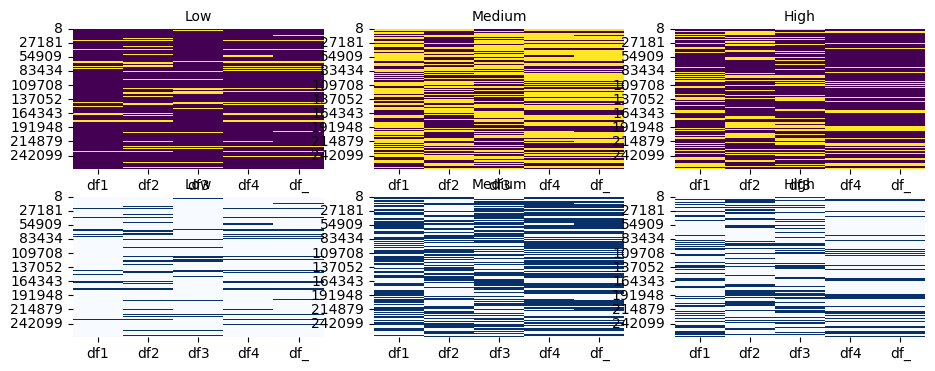


 v.3  ->  LB=0.98118 



,id,df5,df2,df3,df4,df_,wh
269998,899998,Low,Low,Low,Low,Low,L L L L L
269999,899999,Medium,Medium,Medium,Medium,Medium,_ _ _ _ _


'L' - Low,  '_' - Medium,  'H' - High

 wh
L L L L L     159246
_ _ _ _ _      99560
H H H H H       9842
_ H H _ _        226
_ H _ _ _        182
H _ _ H H        166
L L _ L L        137
_ _ H _ _        132
_ L _ _ _        119
_ L L _ _         90
H _ H H H         81
H H _ H H         62
L _ _ L L         45
_ _ L _ _         19
L _ L L L         19
L _ _ _ _         11
_ L L L L         11
_ L L L _          6
L L L L _          6
_ _ _ L L          5
L L _ _ _          5
L L L _ _          5
_ _ _ L _          4
L L _ L _          4
L L L _ L          3
L L _ _ L          3
_ L L _ L          3
_ _ _ _ L          2
L _ _ _ L          2
_ L _ L L          1
_ H H H H          1
_ L _ L _          1
_ L _ _ L          1
Name: count, dtype: int64


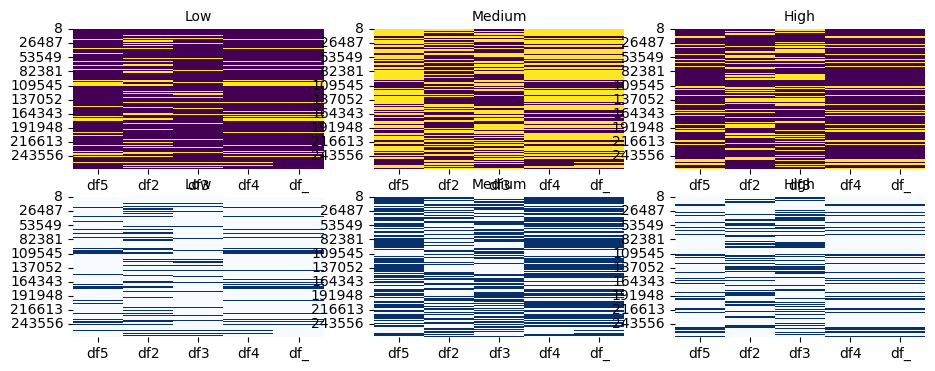


 v.4  ->  LB=? 



,id,df1,df2,df3,df5,df_,wh
269998,899998,Low,Low,Low,Low,Low,L L L L L
269999,899999,Medium,Medium,Medium,Medium,Medium,_ _ _ _ _


'L' - Low,  '_' - Medium,  'H' - High

 wh
L L L L L     159214
_ _ _ _ _      99478
H H H H H       9821
_ H H _ _        187
_ H _ _ _        160
H _ _ H H        155
L L _ L L        125
_ _ H _ _        117
_ L _ _ _        109
_ L L _ _         90
H _ _ _ _         80
H _ H H H         73
H H _ H H         57
H H H _ _         39
L _ _ L L         38
_ L L L L         35
H H _ _ _         22
_ H H H H         21
_ _ L _ _         19
L _ L L L         18
H _ H _ _         15
_ L _ L L         15
_ _ _ L _         11
L L _ _ _         11
_ _ _ H H         11
_ _ _ L L          9
_ L L L _          8
_ _ H H H          8
_ _ _ _ L          7
L L L _ L          7
_ L L _ L          7
_ L _ L _          6
L _ _ _ _          6
L L L _ _          6
_ H _ H H          5
L L _ L _          3
L L L L _          3
_ _ L L L          1
_ L _ _ L          1
H H H _ H          1
L L _ _ L          1
Name: count, dtype: int64


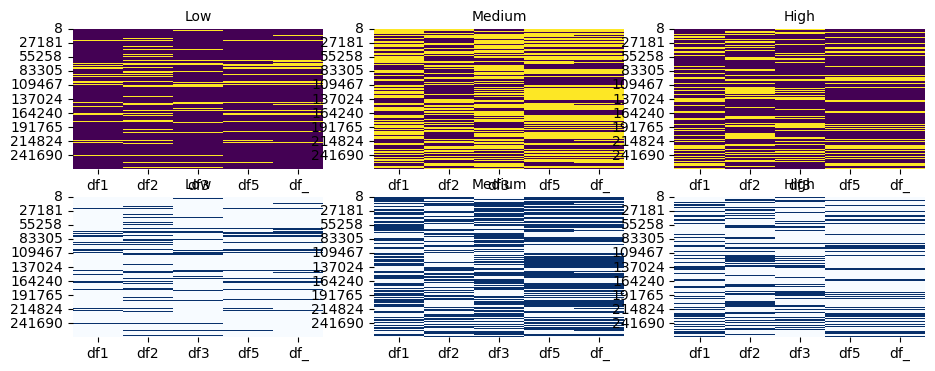


 v.6  ->  LB=0.98118 



,id,df1,df2,df3,df4,df6,df_,wh
269998,899998,Low,Low,Low,Low,Low,Low,L L L L L L
269999,899999,Medium,Medium,Medium,Medium,Medium,Medium,_ _ _ _ _ _


'L' - Low,  '_' - Medium,  'H' - High

 wh
L L L L L L     159217
_ _ _ _ _ _      99485
H H H H H H       9822
_ H H _ _ _        187
_ H _ _ _ _        160
H _ _ H H H        155
L L _ L L L        124
_ _ H _ _ _        117
_ L _ _ _ _        111
_ L L _ _ _         86
H _ _ _ _ _         80
H _ H H H H         73
H H _ H H H         57
_ L L L L L         40
H H H _ _ _         39
L _ _ L L L         38
H H _ _ _ _         22
_ H H H H H         21
_ _ L _ _ _         19
L _ L L L L         18
H _ H _ _ _         15
_ L _ L L L         14
L L _ _ _ _         13
_ _ _ L L L         12
_ L L L _ _         12
_ _ _ H H H         11
L L L _ _ _          9
_ _ H H H H          8
L _ _ _ _ _          6
_ H _ H H H          5
_ _ _ L _ _          4
_ L _ L _ _          4
L L L _ L L          4
_ L L _ L L          2
_ _ _ _ L _          2
L L _ _ L L          2
_ L _ _ L L          2
_ _ _ _ L L          2
_ _ L L L L          1
L L _ L _ _          1
Name: count, dtype: int64


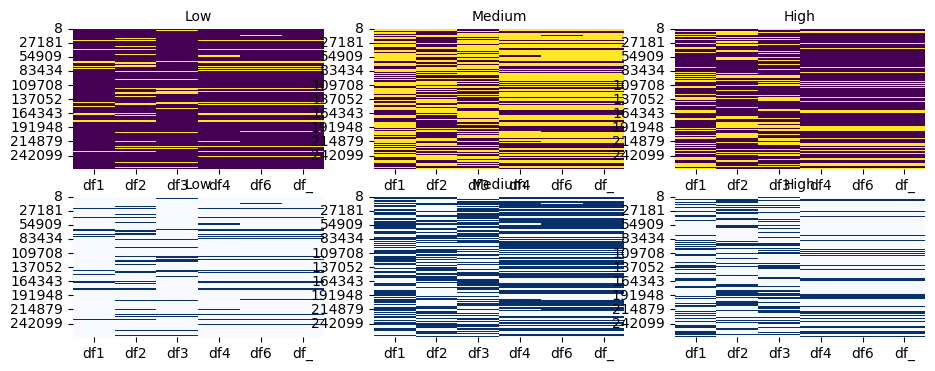


 v.7  ->  ? 



,id,df1,df2,df3,df4,df5,df6,df_,wh
269998,899998,Low,Low,Low,Low,Low,Low,Low,L L L L L L L
269999,899999,Medium,Medium,Medium,Medium,Medium,Medium,Medium,_ _ _ _ _ _ _


'L' - Low,  '_' - Medium,  'H' - High

 wh
L L L L L L L     159213
_ _ _ _ _ _ _      99474
H H H H H H H       9821
_ H H _ _ _ _        187
_ H _ _ _ _ _        160
H _ _ H H H H        155
L L _ L L L L        124
_ _ H _ _ _ _        117
_ L _ _ _ _ _        108
_ L L _ _ _ _         84
H _ _ _ _ _ _         80
H _ H H H H H         73
H H _ H H H H         57
H H H _ _ _ _         39
L _ _ L L L L         38
_ L L L L L L         33
H H _ _ _ _ _         22
_ H H H H H H         21
_ _ L _ _ _ _         19
L _ L L L L L         18
H _ H _ _ _ _         15
_ L _ L L L L         13
L L _ _ _ _ _         11
_ _ _ _ L _ _         11
_ _ _ H H H H         11
_ _ H H H H H          8
_ L L L _ L L          7
_ _ _ L L L L          7
L _ _ _ _ _ _          6
_ L L L _ _ _          6
_ L L L L _ _          6
L L L _ _ _ _          6
_ H _ H H H H          5
_ _ _ L _ L L          5
_ _ _ L _ _ _          4
L L L L _ L L          4
L L L _ L _ _          3
_ L _ _ L _ _          3
L L L _

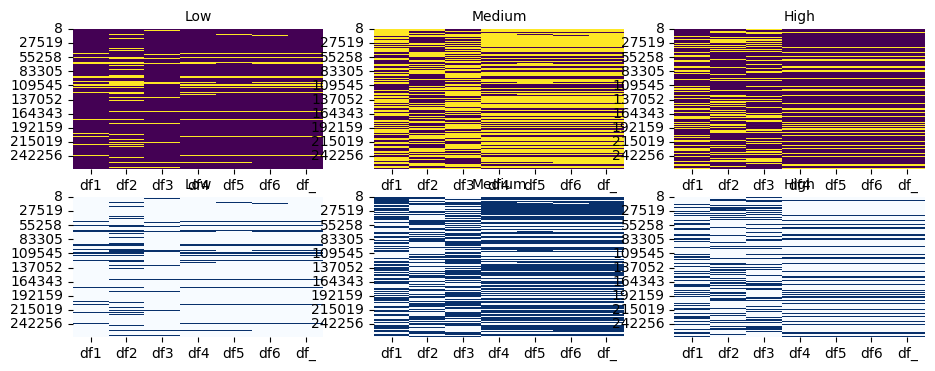

In [3]:
print('\n', 'v.1  ->  LB=0.98118', '\n')

df5   = pd.read_csv(pds+'0.98118.csv')  .rename(columns={'Irrigation_Need':'df5'}) #
df1   = pd.read_csv(pds+'0.98011.c.csv').rename(columns={'Irrigation_Need':'df1'}) #
df2   = pd.read_csv(pds+'0.98011.w.csv').rename(columns={'Irrigation_Need':'df2'}) # =
df3   = pd.read_csv(pds+'0.98039.csv')  .rename(columns={'Irrigation_Need':'df3'}) # =
df4   = pd.read_csv(pds+'0.98113.csv')  .rename(columns={'Irrigation_Need':'df4'}) # =
df_   = pd.read_csv(pds+'0.98119.csv')  .rename(columns={'Irrigation_Need':'df_'}) # =
D,N   = [df5,df1,df2,df3,df4,df_], ['df5','df1','df2','df3','df4','df_']           # 
dfs   = merge(D)                                                                   #  
dfv1  = vote (N, f_vote_schema3, dfs, details=True) ;display_heatmaps(N,dfs,qp=6)  #

print('\n', 'v.2  ->  LB=0.98118', '\n')	

df1   = pd.read_csv(pds+'0.98011.c.csv').rename(columns={'Irrigation_Need':'df1'}) #
df2   = pd.read_csv(pds+'0.98011.w.csv').rename(columns={'Irrigation_Need':'df2'}) # =
df3   = pd.read_csv(pds+'0.98039.csv')  .rename(columns={'Irrigation_Need':'df3'}) # =
df4   = pd.read_csv(pds+'0.98113.csv')  .rename(columns={'Irrigation_Need':'df4'}) # =
df_   = pd.read_csv(pds+'0.98119.csv')  .rename(columns={'Irrigation_Need':'df_'}) # =
D,N   = [df1,df2,df3,df4,df_], ['df1','df2','df3','df4','df_']                     # 
dfs   = merge(D)                                                                   #  
dfv2  = vote (N, f_vote_schema1, dfs, details=True) ;display_heatmaps(N,dfs,qp=5)  #

print('\n', 'v.3  ->  LB=0.98118', '\n')	

df5   = pd.read_csv(pds+'0.98118.csv')  .rename(columns={'Irrigation_Need':'df5'}) #
df2   = pd.read_csv(pds+'0.98011.w.csv').rename(columns={'Irrigation_Need':'df2'}) # =
df3   = pd.read_csv(pds+'0.98039.csv')  .rename(columns={'Irrigation_Need':'df3'}) # =
df4   = pd.read_csv(pds+'0.98113.csv')  .rename(columns={'Irrigation_Need':'df4'}) # =
df_   = pd.read_csv(pds+'0.98119.csv')  .rename(columns={'Irrigation_Need':'df_'}) # =
D,N   = [df5,df2,df3,df4,df_], ['df5','df2','df3','df4','df_']                     # 
dfs   = merge(D)                                                                   #  
dfv3  = vote (N, f_vote_schema1, dfs, details=True) ;display_heatmaps(N,dfs,qp=5)  #

print('\n', 'v.4  ->  LB=?', '\n')

df1   = pd.read_csv(pds+'0.98011.c.csv').rename(columns={'Irrigation_Need':'df1'}) #
df2   = pd.read_csv(pds+'0.98011.w.csv').rename(columns={'Irrigation_Need':'df2'}) # =
df3   = pd.read_csv(pds+'0.98039.csv')  .rename(columns={'Irrigation_Need':'df3'}) # =
df5   = pd.read_csv(pds+'0.98118.csv')  .rename(columns={'Irrigation_Need':'df5'}) #
df_   = pd.read_csv(pds+'0.98119.csv')  .rename(columns={'Irrigation_Need':'df_'}) # =
D,N   = [df1,df2,df3,df5,df_], ['df1','df2','df3','df5','df_']                     # 
dfs   = merge(D)                                                                   #  
dfv4  = vote (N, f_vote_schema1, dfs, details=True) ;display_heatmaps(N,dfs,qp=5)  #

print('\n', 'v.6  ->  LB=0.98118', '\n')

df1   = pd.read_csv(pds+'0.98011.c.csv') .rename(columns={'Irrigation_Need':'df1'}) #
df2   = pd.read_csv(pds+'0.98011.w.csv') .rename(columns={'Irrigation_Need':'df2'}) # =
df3   = pd.read_csv(pds+'0.98039.csv')   .rename(columns={'Irrigation_Need':'df3'}) # =
df4   = pd.read_csv(pds+'0.98113.csv')   .rename(columns={'Irrigation_Need':'df4'}) # =
df6   = pd.read_csv(pds+'0.98119.csv')   .rename(columns={'Irrigation_Need':'df6'}) #
df_   = pd.read_csv(pds+'0.98118.v1.csv').rename(columns={'Irrigation_Need':'df_'}) # =
D,N   = [df1,df2,df3,df4,df6,df_], ['df1','df2','df3','df4','df6','df_']            # 
dfs   = merge(D)                                                                    #  
dfv6  = vote (N, f_vote_schema3, dfs, details=True) ;display_heatmaps(N,dfs,qp=6)   #


print('\n', 'v.7  ->  ?', '\n')

df1   = pd.read_csv(pds+'0.98011.c.csv') .rename(columns={'Irrigation_Need':'df1'}) #
df2   = pd.read_csv(pds+'0.98011.w.csv') .rename(columns={'Irrigation_Need':'df2'}) # =
df3   = pd.read_csv(pds+'0.98039.csv')   .rename(columns={'Irrigation_Need':'df3'}) # =
df4   = pd.read_csv(pds+'0.98113.csv')   .rename(columns={'Irrigation_Need':'df4'}) # =
df5   = pd.read_csv(pds+'0.98118.csv')   .rename(columns={'Irrigation_Need':'df5'}) # =
df6   = pd.read_csv(pds+'0.98119.csv')   .rename(columns={'Irrigation_Need':'df6'}) #
df_   = pd.read_csv(pds+'0.98118.v1.csv').rename(columns={'Irrigation_Need':'df_'}) # =
D,N   = [df1,df2,df3,df4,df5,df6,df_], ['df1','df2','df3','df4','df5','df6','df_']  # 
dfs   = merge(D)                                                                    #  
dfv7  = vote (N, f_vote_schema3, dfs, details=True) ;display_heatmaps(N,dfs,qp=7)   #


,id,df1,df2,df3,df4,df5,df_,wh
269998,899998,Low,Low,Low,Low,Low,Low,L L L L L L
269999,899999,Medium,Medium,Medium,Medium,Medium,Medium,_ _ _ _ _ _


'L' - Low,  '_' - Medium,  'H' - High

 wh
L L L L L L     159453
_ _ _ _ _ _     100339
H H H H H H      10151
_ _ _ _ L _         22
L L L L _ L         16
_ _ L _ L _          6
L L L _ _ L          5
_ _ _ L L _          3
_ _ _ _ _ L          2
L _ L L L L          2
H H H H _ H          1
Name: count, dtype: int64


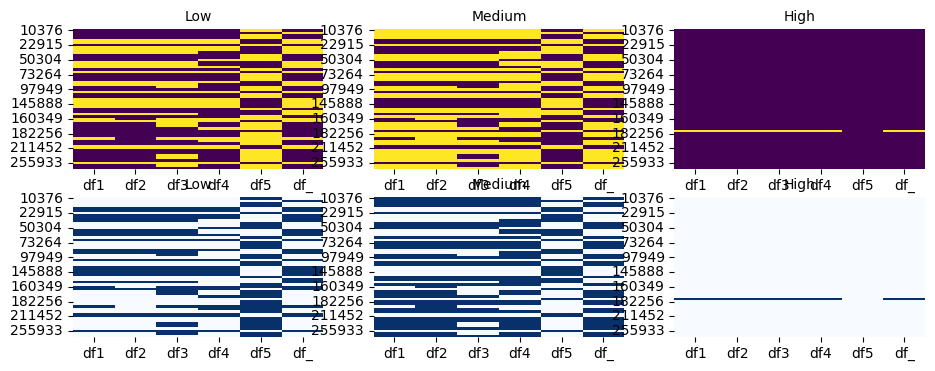

In [4]:
df1   = pd.read_csv(pds+'0.98118.v1.csv').rename(columns={'Irrigation_Need':'df1'}) # v.1
df2   = pd.read_csv(pds+'0.98118.v2.csv').rename(columns={'Irrigation_Need':'df2'}) # v.2
df3   = pd.read_csv(pds+'0.98118.v3.csv').rename(columns={'Irrigation_Need':'df3'}) # v.3
df4   = pd.read_csv(pds+'0.98118.v4.csv').rename(columns={'Irrigation_Need':'df4'}) # v.4
df5   = pd.read_csv(pds+'0.98118.csv')   .rename(columns={'Irrigation_Need':'df5'}) # v.o
df_   = pd.read_csv(pds+'0.98119.csv')   .rename(columns={'Irrigation_Need':'df_'}) #
D,N   = [df1,df2,df3,df4,df5,df_], ['df1','df2','df3','df4','df5','df_']            # 
dfs   = merge(D)                                                                    #  
dfv8  = vote (N, f_vote_schema3, dfs, details=True)   ;display_heatmaps(N,dfs,qp=6) #

,id,df8,df5,df2,df3,df4,df7,df9,wh
269998,899998,Low,Low,Low,Low,Low,Low,Low,L L L L L L L
269999,899999,Medium,Medium,Medium,Medium,Medium,Medium,Medium,_ _ _ _ _ _ _


'L' - Low,  '_' - Medium,  'H' - High

 wh
L L L L L L L     159214
_ _ _ _ _ _ _      99471
H H H H H H H       9822
H _ _ H _ _ _        187
_ _ _ H _ _ _        160
_ H H _ H H H        155
_ L L L L L L        124
H _ _ _ _ _ _        117
_ _ _ L _ _ _        106
L _ _ L _ _ _         82
_ _ H _ _ _ _         80
H H H _ H H H         73
_ H H H H H H         57
H _ H H _ _ _         39
_ L L _ L L L         38
L L _ L L L L         37
_ _ H H _ _ _         22
H H _ H H H H         21
L _ _ _ _ _ _         19
L L L _ L L L         18
H _ H _ _ _ _         15
_ L _ L L L L         14
L L _ L L _ _         12
_ H _ _ H H H         11
_ L _ _ L L L          9
_ _ L L _ _ _          8
H H _ _ H H H          8
_ _ _ _ _ L _          7
_ L _ _ _ _ _          6
L L L L _ _ _          6
_ H _ H H H H          5
_ L L L _ _ _          5
_ _ L _ _ _ _          5
_ L _ L _ _ _          5
_ L _ _ L _ _          4
_ _ _ _ _ L L          4
L L L L _ L L          4
_ L _ L L _ _          4
L _ L L

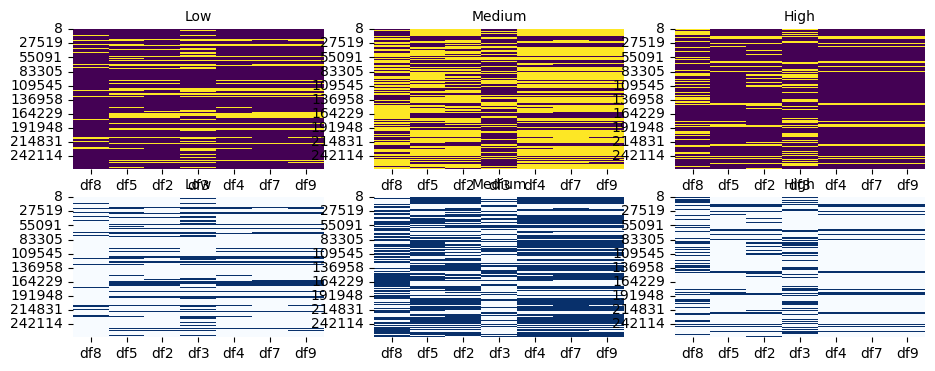

In [5]:
df8   = pd.read_csv(pds+'0.98039.csv')   .rename(columns={'Irrigation_Need':'df8'}) #
df5   = pd.read_csv(pds+'0.98114.csv')   .rename(columns={'Irrigation_Need':'df5'}) #

df2   = pd.read_csv(pds+'0.98011.c.csv') .rename(columns={'Irrigation_Need':'df2'}) #
df3   = pd.read_csv(pds+'0.98011.w.csv') .rename(columns={'Irrigation_Need':'df3'}) #

df4   = pd.read_csv(pds+'0.98113.csv')   .rename(columns={'Irrigation_Need':'df4'}) # 
df7   = pd.read_csv(pds+'0.98117.csv')   .rename(columns={'Irrigation_Need':'df7'}) #

df9   = pd.read_csv(pds+'0.98119.csv')   .rename(columns={'Irrigation_Need':'df9'}) #

D,N   = [df8,df5,df2,df3,df4,df7,df9], ['df8','df5','df2','df3','df4','df7','df9']  #
dfs   = merge(D)                                                                    #  
dfv8  = vote (N, f_vote_schema2, dfs, details=True)   ;display_heatmaps(N,dfs,qp=7) #

,id,df8,df5,df3,df4,df7,df9,wh
269998,899998,Low,Low,Low,Low,Low,Low,L L L L L L
269999,899999,Medium,Medium,Medium,Medium,Medium,Medium,_ _ _ _ _ _


'L' - Low,  '_' - Medium,  'H' - High

 wh
L L L L L L     159251
_ _ _ _ _ _      99556
H H H H H H       9843
H _ H _ _ _        226
_ _ H _ _ _        182
_ H _ H H H        166
_ L L L L L        138
H _ _ _ _ _        132
_ _ L _ _ _        114
L _ L _ _ _         85
H H _ H H H         81
_ H H H H H         62
_ L _ L L L         47
L _ _ _ _ _         19
L L _ L L L         19
L L L L _ _         12
_ L L _ _ _         10
L L L _ _ _          9
_ L _ _ _ _          7
_ _ _ _ L _          7
L L L _ L L          6
L L L L _ L          6
_ L L L _ _          5
_ _ _ _ L L          4
_ L _ L _ _          4
_ L _ L _ L          3
_ _ L _ L L          2
_ L L _ _ L          2
_ L _ _ L _          1
L _ L _ L _          1
Name: count, dtype: int64


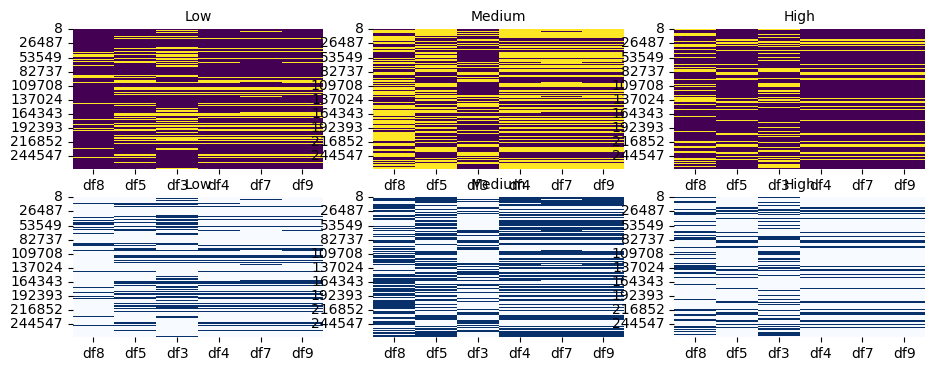

In [6]:
df8   = pd.read_csv(pds+'0.98039.csv')   .rename(columns={'Irrigation_Need':'df8'}) #
df5   = pd.read_csv(pds+'0.98114.csv')   .rename(columns={'Irrigation_Need':'df5'}) #

#df2   = pd.read_csv(pds+'0.98011.c.csv') .rename(columns={'Irrigation_Need':'df2'})  #
df3   = pd.read_csv(pds+'0.98011.w.csv') .rename(columns={'Irrigation_Need':'df3'}) #

df4   = pd.read_csv(pds+'0.98113.csv')   .rename(columns={'Irrigation_Need':'df4'}) # 
df7   = pd.read_csv(pds+'0.98117.csv')   .rename(columns={'Irrigation_Need':'df7'}) #

df9   = pd.read_csv(pds+'0.98119.csv')   .rename(columns={'Irrigation_Need':'df9'}) #

D,N   = [df8,df5,df3,df4,df7,df9], ['df8','df5','df3','df4','df7','df9']            #
dfs   = merge(D)                                                                    #  
dfv9  = vote (N, f_vote_schema3, dfs, details=True)   
display_heatmaps(N,dfs,qp=6) #id	df8	df5	df3	df4	df7	df9	

In [7]:
df = dfv9

In [8]:
df.to_csv('submission_bitch.csv',index=False)
df

,id,Irrigation_Need
0,630000,Low
1,630001,Low
2,630002,Low
3,630003,Low
4,630004,Low
...,...,...
269995,899995,Medium
269996,899996,Low
269997,899997,Medium
269998,899998,Low
